# ECG AI Statistical Validation Report

**Dataset:** PTB-XL (v1.0.3) — PhysioNet  
**Task:** Multi-label diagnostic superclass classification (5 classes)  
**Test set:** Fold 10 (n=2,158, human-validated labels)  
**Primary endpoint:** Macro-AUC on held-out test set  

---

## Study Summary

This report presents the statistical validation of a 1D ResNet deep learning 
model for automated ECG classification trained on the PTB-XL dataset. 
Results are compared against logistic regression and random forest baselines. 
All reported metrics are computed on the held-out test set (fold 10) which 
was not used during model development or hyperparameter selection.

---

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import auc, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import sys

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path.cwd().parent
ARTIFACTS = ROOT / 'artifacts'
sys.path.append(str(Path.cwd().parent / 'modules'))

# ── Constants ─────────────────────────────────────────────────────────────────
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
COLORS = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E', '#7F77DD']
SEED = 42

# ── Load all artifacts ────────────────────────────────────────────────────────
print("Loading artifacts...")

# Probabilities
lr_test_probs = np.load(ARTIFACTS / 'log_test_probs.npy')
rf_test_probs = np.load(ARTIFACTS / 'rf_test_probs.npy')
resnet_test_probs = np.load(ARTIFACTS / 'resnet_test_probs.npy')
test_labels = np.load(ARTIFACTS / 'resnet_test_labels.npy')

# Precomputed results
macro_ci = pd.read_csv(ARTIFACTS / 'macro_auc_ci.csv', index_col=0)
class_ci = pd.read_csv(ARTIFACTS / 'resnet_class_auc_ci.csv', index_col=0)
delong = pd.read_csv(ARTIFACTS / 'delong_results.csv', index_col=[0,1])
subgroup = pd.read_excel(ARTIFACTS / 'subgroup_analysis.xlsx', sheet_name='Summary', index_col=0)

# Classification metrics
resnet_metrics = pd.read_csv(ARTIFACTS / 'resnet_classification_metrics.csv',
                              index_col=0)
lr_metrics     = pd.read_csv(ARTIFACTS / 'lr_classification_metrics.csv',
                              index_col=0)
rf_metrics     = pd.read_csv(ARTIFACTS / 'rf_classification_metrics.csv',
                              index_col=0)

print("All artifacts loaded successfully")
print(f"Test set size: {len(test_labels):,} records")
print(f"Label matrix: {test_labels.shape}")

Loading artifacts...
All artifacts loaded successfully
Test set size: 2,158 records
Label matrix: (2158, 5)


In [3]:
# ── Section 1: Final Results Table ───────────────────────────────────────────

# Model comparison — macro AUC with 95% CI
print("=" * 65)
print("TABLE 1 — Primary endpoint: Macro-AUC with 95% bootstrap CI")
print("=" * 65)
print(macro_ci)

print("\n")

# Per-class AUC — ResNet1D
print("=" * 65)
print("TABLE 2 — ResNet1D per-class AUC with 95% bootstrap CI")
print("=" * 65)
print(class_ci[['AUC', 'CI Lower', 'CI Upper', 'CI 95%']])

print("\n")

# Sensitivity, specificity, F1 comparison
print("=" * 65)
print("TABLE 3 — Classification metrics at optimal threshold")
print("=" * 65)
metrics_comparison = pd.DataFrame({
    'LR Sens':       lr_metrics['Sensitivity'],
    'RF Sens':       rf_metrics['Sensitivity'],
    'ResNet Sens':   resnet_metrics['Sensitivity'],
    'LR Spec':       lr_metrics['Specificity'],
    'RF Spec':       rf_metrics['Specificity'],
    'ResNet Spec':   resnet_metrics['Specificity'],
    'LR F1':         lr_metrics['F1'],
    'RF F1':         rf_metrics['F1'],
    'ResNet F1':     resnet_metrics['F1'],
})
print(metrics_comparison.to_string())

TABLE 1 — Primary endpoint: Macro-AUC with 95% bootstrap CI
                                     95% CI
Model                                      
Logistic Regression  0.8528 (0.8433–0.8632)
Random Forest        0.8628 (0.8535–0.8726)
ResNet1D             0.9038 (0.8959–0.9115)


TABLE 2 — ResNet1D per-class AUC with 95% bootstrap CI
          AUC  CI Lower  CI Upper                  CI 95%
Class                                                    
NORM   0.9340    0.9239    0.9438  0.9340 (0.9239–0.9438)
MI     0.9142    0.9015    0.9264  0.9142 (0.9015–0.9264)
STTC   0.9182    0.9059    0.9303  0.9182 (0.9059–0.9303)
CD     0.9055    0.8878    0.9218  0.9055 (0.8878–0.9218)
HYP    0.8469    0.8224    0.8700  0.8469 (0.8224–0.8700)


TABLE 3 — Classification metrics at optimal threshold
              LR Sens  RF Sens  ResNet Sens  LR Spec  RF Spec  ResNet Spec   LR F1   RF F1  ResNet F1
NORM           0.9190   0.9086       0.9252   0.7180   0.7531       0.7908  0.8101  0.8204     0.84

In [4]:
# ── Section 2: Statistical Comparison ────────────────────────────────────────
print("=" * 65)
print("TABLE 4 — DeLong test: ResNet1D vs baselines")
print("=" * 65)
print(delong[['AUC ResNet1D', 'AUC Baseline', 'Delta AUC',
              'Z-stat', 'P-value', 'Significant']].to_string())

# Highlight non-significant results
print("\nNote: STTC is the only class where ResNet1D does not")
print("significantly outperform either baseline (p > 0.05).")

TABLE 4 — DeLong test: ResNet1D vs baselines
                                       AUC ResNet1D  AUC Baseline  Delta AUC  Z-stat   P-value Significant
Comparison                      Class                                                                     
ResNet1D vs Logistic Regression Macro        0.9038        0.8528     0.0509  3.8154  0.000136         Yes
                                NORM         0.9340        0.8980     0.0360  4.3639  0.000013         Yes
                                MI           0.9142        0.8115     0.1027  8.3085  0.000000         Yes
                                STTC         0.9182        0.9078     0.0104  1.0731  0.283242          No
                                CD           0.9055        0.8419     0.0636  4.5030  0.000007         Yes
                                HYP          0.8469        0.8050     0.0419  2.1614  0.030661         Yes
ResNet1D vs Random Forest       Macro        0.9038        0.8628     0.0409  3.1596  0.001580     

In [5]:
# ── Section 3: Calibration ────────────────────────────────────────────────────
print("=" * 65)
print("TABLE 5 — Calibration metrics (ECE and Brier score)")
print("=" * 65)

# Recompute from probabilities for clean reporting
def compute_ece(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return round(float(ece), 4)

cal_table = pd.DataFrame({
    'LR ECE':      [compute_ece(test_labels[:, i], lr_test_probs[:, i])
                    for i in range(5)] +
                   [round(np.mean([compute_ece(test_labels[:, i],
                    lr_test_probs[:, i]) for i in range(5)]), 4)],
    'RF ECE':      [compute_ece(test_labels[:, i], rf_test_probs[:, i])
                    for i in range(5)] +
                   [round(np.mean([compute_ece(test_labels[:, i],
                    rf_test_probs[:, i]) for i in range(5)]), 4)],
    'ResNet ECE':  [compute_ece(test_labels[:, i], resnet_test_probs[:, i])
                    for i in range(5)] +
                   [round(np.mean([compute_ece(test_labels[:, i],
                    resnet_test_probs[:, i]) for i in range(5)]), 4)],
    'ResNet Brier':[round(float(np.mean((resnet_test_probs[:, i] -
                    test_labels[:, i]) ** 2)), 4)
                    for i in range(5)] +
                   [round(float(np.mean((resnet_test_probs -
                    test_labels) ** 2)), 4)],
}, index=CLASS_ORDER + ['Macro (mean)'])

print(cal_table.to_string())
print("\nNote: Temperature scaling produced negligible improvement")
print("(macro ECE: 0.1006 → 1.009). Miscalibration attributed to")
print("class imbalance rather than uniform overconfidence.")

TABLE 5 — Calibration metrics (ECE and Brier score)
              LR ECE  RF ECE  ResNet ECE  ResNet Brier
NORM          0.0288  0.0402      0.0260        0.1023
MI            0.0210  0.0340      0.1244        0.1234
STTC          0.0227  0.0494      0.0980        0.1111
CD            0.0237  0.0422      0.1074        0.1101
HYP           0.0246  0.0178      0.1470        0.1270
Macro (mean)  0.0242  0.0367      0.1006        0.1148

Note: Temperature scaling produced negligible improvement
(macro ECE: 0.1006 → 1.009). Miscalibration attributed to
class imbalance rather than uniform overconfidence.


In [6]:
# ── Section 4: Subgroup Analysis ─────────────────────────────────────────────
print("=" * 65)
print("TABLE 6 — Subgroup analysis: Macro-AUC by patient subgroup")
print("=" * 65)

subgroup_summary = pd.DataFrame({
    'Subgroup':  list(subgroup.columns),
    'Macro AUC': [subgroup.loc['Macro (mean)', col]
                  for col in subgroup.columns],
    'Group':     ['Sex', 'Sex',
                  'Age', 'Age', 'Age', 'Age',
                  'Quality', 'Quality']
}).set_index('Subgroup')

print(subgroup_summary.to_string())
print("\nOverall test AUC: 0.9038")
print("Largest gap:      >80 age group (0.857) vs overall (0.904)")
print("Most robust:      Clean vs Noisy (0.904 vs 0.903)")

TABLE 6 — Subgroup analysis: Macro-AUC by patient subgroup
          Macro AUC    Group
Subgroup                    
Female       0.9105      Sex
Male         0.8979      Sex
<40          0.9007      Age
40-60        0.8909      Age
60-80        0.8953      Age
>80          0.8574      Age
Clean        0.9043  Quality
Noisy        0.9028  Quality

Overall test AUC: 0.9038
Largest gap:      >80 age group (0.857) vs overall (0.904)
Most robust:      Clean vs Noisy (0.904 vs 0.903)


# ── Section 5: Limitations ───────────────────────────────────────────────────
## Limitations

1. **Sampling rate** — Model trained at 100 Hz (below the recommended 
   clinical standard of 512 Hz). Performance may improve with 500 Hz input.

2. **Calibration** — ResNet1D macro ECE of 0.101 indicates poor probability 
   calibration, particularly for rare classes (HYP ECE=0.147, Brier Skill=-0.191). 
   Temperature scaling did not meaningfully improve calibration, suggesting 
   class imbalance as the primary driver. Per-class isotonic regression on a 
   larger calibration set is recommended.

3. **Age subgroup** — The <40 age group contains very few pathological cases 
   (MI n=7, HYP n=11). AUC estimates for this subgroup should be interpreted 
   with caution due to high variance.

4. **External validation** — All results are from PTB-XL fold 10. No external 
   validation cohort was used. Generalisability to signals from different 
   devices, institutions, or patient populations is unknown.

5. **Single dataset** — PTB-XL was collected between 1989–1996 from a single 
   institution. Contemporary ECG devices and patient demographics may differ.

# ── Section 6: Conclusions ────────────────────────────────────────────────────
## Conclusions

ResNet1D achieved a macro-AUC of **0.9038 (95% CI: 0.8959–0.9115)** on the 
held-out test set, significantly outperforming logistic regression 
(0.8528, p=0.000136) and random forest (0.8628, p=0.001580) via DeLong test.

The largest per-class improvement over logistic regression was observed for 
MI (ΔAUC=+0.103, p<0.001) and CD (ΔAUC=+0.064, p<0.001), consistent with 
the hypothesis that convolutional networks better capture morphological 
ECG features than hand-crafted statistical features.

Performance was consistent across sex and signal quality subgroups. A 
meaningful performance decline was observed in patients aged >80 
(AUC=0.857 vs overall 0.904), warranting further investigation.

Calibration requires improvement before clinical deployment — particularly 
for rare diagnostic classes where probability estimates may not be reliable 
as absolute risk scores.

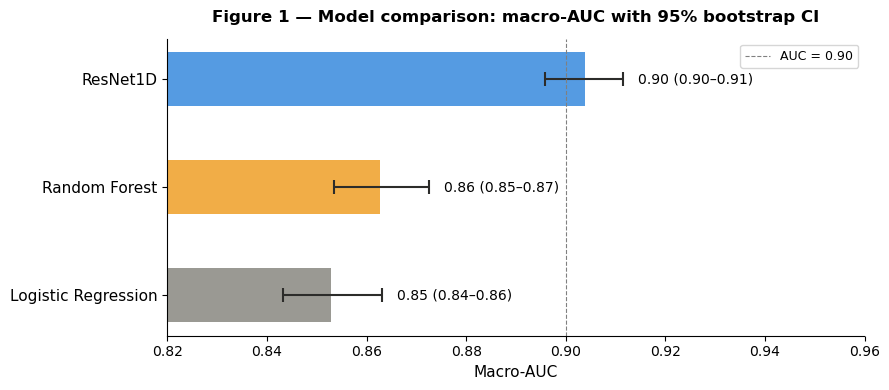

Figure 1 saved


In [7]:
# Makes Figures directory if it does not exist
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# Define the coloring for models
MODEL_COLORS = {
    'Logistic Regression': '#888780',
    'Random Forest':       '#EF9F27',
    'ResNet1D':            '#378ADD',
}
CLASS_COLORS = dict(zip(CLASS_ORDER, COLORS)) # Define the class colors

# Define function to make Figure 1 (Model AUC Comparisons)
def figure1_model_comparison() -> plt.Figure:
    """
    Forest plot showing macro-AUC with 95% bootstrap CI
    for all three models.
    """
    models = ['Logistic Regression', 'Random Forest', 'ResNet1D']
    aucs   = [0.8528, 0.8628, 0.9038]
    lowers = [0.8433, 0.8535, 0.8959]
    uppers = [0.8632, 0.8726, 0.9115]

    fig, ax = plt.subplots(figsize=(9, 4))

    for i, (model, est, lo, hi) in enumerate(
            zip(models, aucs, lowers, uppers)):
        color = MODEL_COLORS[model]
        ax.barh(i, est, height=0.5, color=color,
                alpha=0.85, edgecolor='none')
        ax.errorbar(est, i,
                    xerr=[[est - lo], [hi - est]],
                    fmt='none', color='#2C2C2A',
                    elinewidth=1.5, capsize=5, capthick=1.5)
        ax.text(hi + 0.003, i,
                f"{est:.2f} ({lo:.2f}–{hi:.2f})",
                va='center', fontsize=10)

    ax.axvline(0.9, color='gray', linewidth=0.8,
               linestyle='--', label='AUC = 0.90')
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=11)
    ax.set_xlabel('Macro-AUC', fontsize=11)
    ax.set_title('Figure 1 — Model comparison: macro-AUC with 95% bootstrap CI',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlim(0.82, 0.96)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig

fig1 = figure1_model_comparison()
plt.show()
fig1.savefig(FIGURES / 'figure1_model_comparison.png',
             dpi=150, bbox_inches='tight')
print("Figure 1 saved")

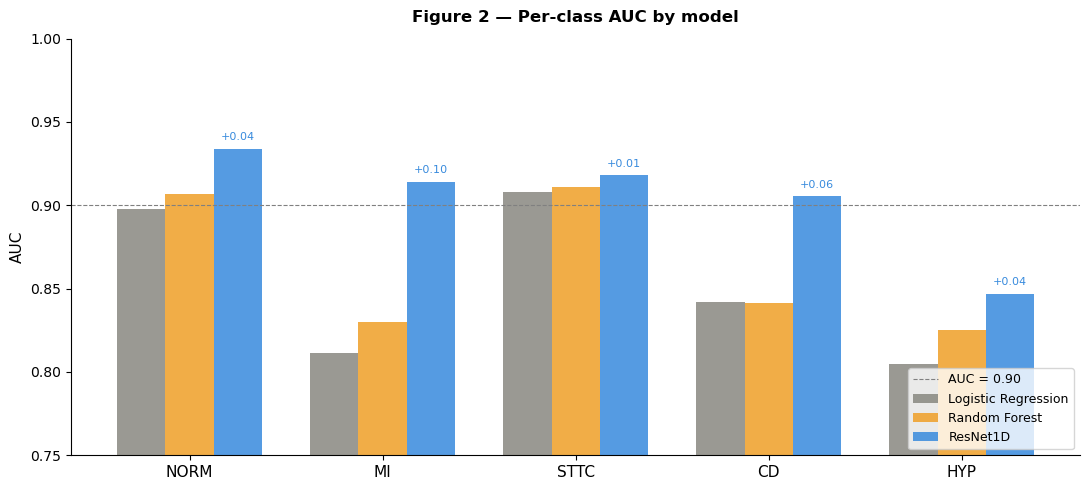

Figure 2 saved


In [8]:
# Define function to make Figure 2 per class AUC

def figure2_per_class_auc() -> plt.Figure:
    """
    Grouped bar chart showing per-class AUC for all three models.
    """
    lr_aucs     = [0.8980, 0.8115, 0.9078, 0.8419, 0.8050]
    rf_aucs     = [0.9066, 0.8300, 0.9107, 0.8416, 0.8253]
    resnet_aucs = [0.9340, 0.9142, 0.9182, 0.9055, 0.8469]

    x     = np.arange(len(CLASS_ORDER))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))

    bars_lr = ax.bar(x - width, lr_aucs, width,
                     label='Logistic Regression',
                     color=MODEL_COLORS['Logistic Regression'],
                     edgecolor='none', alpha=0.85)
    bars_rf = ax.bar(x, rf_aucs, width,
                     label='Random Forest',
                     color=MODEL_COLORS['Random Forest'],
                     edgecolor='none', alpha=0.85)
    bars_rn = ax.bar(x + width, resnet_aucs, width,
                     label='ResNet1D',
                     color=MODEL_COLORS['ResNet1D'],
                     edgecolor='none', alpha=0.85)

    # Annotate ResNet1D bars with delta over LR
    for i, (rn, lr) in enumerate(zip(resnet_aucs, lr_aucs)):
        delta = rn - lr
        ax.text(x[i] + width, rn + 0.005,
                f'+{delta:.2f}', ha='center',
                fontsize=8, color=MODEL_COLORS['ResNet1D'],
                fontweight='500')

    ax.axhline(0.9, color='gray', linewidth=0.8,
               linestyle='--', label='AUC = 0.90')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_ORDER, fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_ylim(0.75, 1.00)
    ax.set_title('Figure 2 — Per-class AUC by model',
                 fontsize=12, fontweight='bold', pad=12)
    ax.legend(fontsize=9, loc='lower right')
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig

fig2 = figure2_per_class_auc()
plt.show()
fig2.savefig(FIGURES / 'figure2_per_class_auc.png',
             dpi=150, bbox_inches='tight')
print("Figure 2 saved")

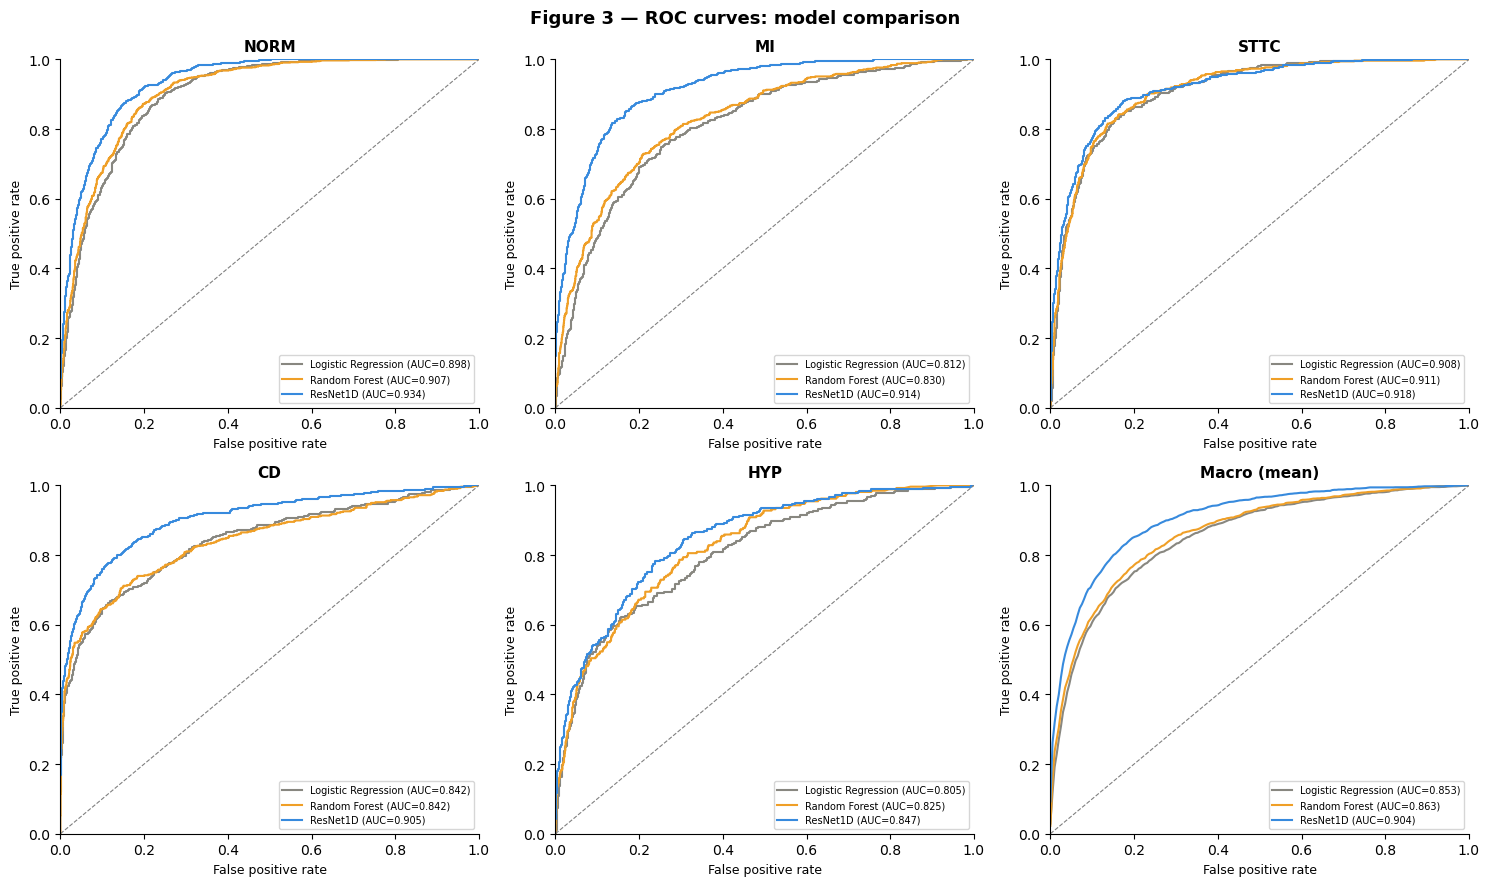

Figure 3 saved


In [9]:
def figure3_roc_curves() -> plt.Figure:
    """
    ROC curves for all models — one subplot per class plus macro.
    """
    model_probs = {
        'Logistic Regression': lr_test_probs,
        'Random Forest':       rf_test_probs,
        'ResNet1D':            resnet_test_probs,
    }

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes      = axes.flatten()

    for i, cls in enumerate(CLASS_ORDER):
        ax = axes[i]
        for model_name, probs in model_probs.items():
            fpr, tpr, _ = roc_curve(test_labels[:, i], probs[:, i])
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=MODEL_COLORS[model_name],
                    linewidth=1.5,
                    label=f"{model_name} (AUC={roc_auc:.3f})")
        ax.plot([0, 1], [0, 1], color='gray',
                linewidth=0.8, linestyle='--')
        ax.set_title(cls, fontsize=11, fontweight='bold')
        ax.set_xlabel('False positive rate', fontsize=9)
        ax.set_ylabel('True positive rate', fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.legend(fontsize=7, loc='lower right')
        sns.despine(ax=ax)

    # Macro subplot
    ax        = axes[5]
    mean_fpr  = np.linspace(0, 1, 200)
    for model_name, probs in model_probs.items():
        tprs = []
        for i in range(len(CLASS_ORDER)):
            fpr, tpr, _ = roc_curve(test_labels[:, i], probs[:, i])
            tprs.append(np.interp(mean_fpr, fpr, tpr))
        mean_tpr      = np.mean(tprs, axis=0)
        mean_tpr[-1]  = 1.0
        macro_auc_val = auc(mean_fpr, mean_tpr)
        ax.plot(mean_fpr, mean_tpr,
                color=MODEL_COLORS[model_name], linewidth=1.5,
                label=f"{model_name} (AUC={macro_auc_val:.3f})")
    ax.plot([0, 1], [0, 1], color='gray',
            linewidth=0.8, linestyle='--')
    ax.set_title('Macro (mean)', fontsize=11, fontweight='bold')
    ax.set_xlabel('False positive rate', fontsize=9)
    ax.set_ylabel('True positive rate', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='lower right')
    sns.despine(ax=ax)

    fig.suptitle('Figure 3 — ROC curves: model comparison',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

fig3 = figure3_roc_curves()
plt.show()
fig3.savefig(FIGURES / 'figure3_roc_curves.png',
             dpi=150, bbox_inches='tight')
print("Figure 3 saved")

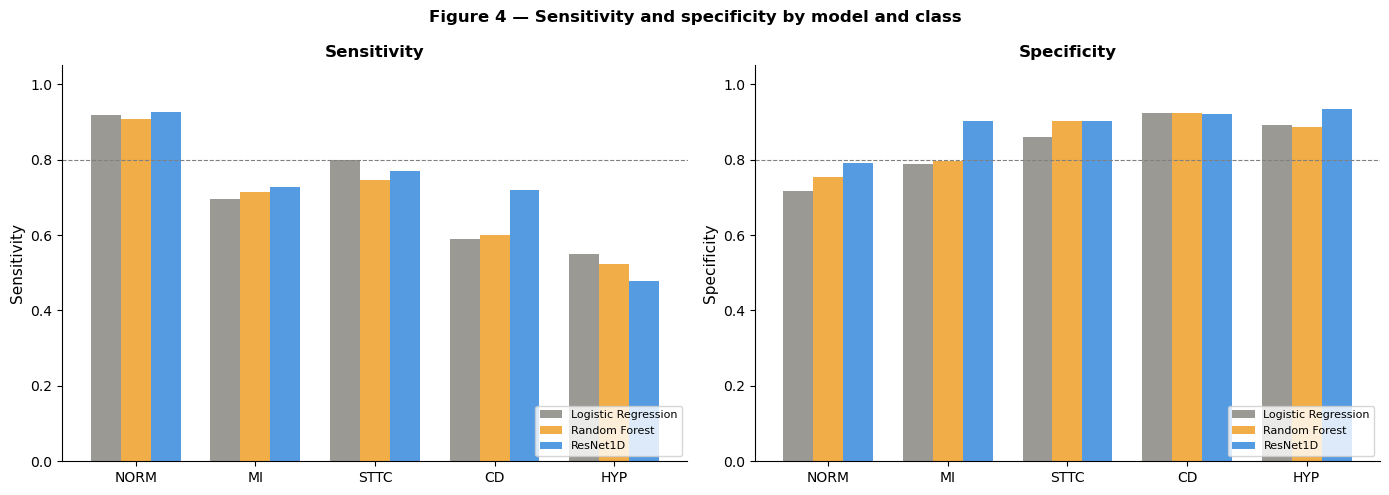

Figure 4 saved


In [10]:
def figure4_sens_spec() -> plt.Figure:
    """
    Grouped bar chart comparing sensitivity and specificity
    per class across all three models.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, ['Sensitivity', 'Specificity']):
        lr_vals     = lr_metrics.loc[CLASS_ORDER, metric].values
        rf_vals     = rf_metrics.loc[CLASS_ORDER, metric].values
        resnet_vals = resnet_metrics.loc[CLASS_ORDER, metric].values

        x     = np.arange(len(CLASS_ORDER))
        width = 0.25

        ax.bar(x - width, lr_vals, width,
               label='Logistic Regression',
               color=MODEL_COLORS['Logistic Regression'],
               edgecolor='none', alpha=0.85)
        ax.bar(x, rf_vals, width,
               label='Random Forest',
               color=MODEL_COLORS['Random Forest'],
               edgecolor='none', alpha=0.85)
        ax.bar(x + width, resnet_vals, width,
               label='ResNet1D',
               color=MODEL_COLORS['ResNet1D'],
               edgecolor='none', alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_ORDER, fontsize=10)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='lower right')
        ax.axhline(0.8, color='gray', linewidth=0.8, linestyle='--')
        sns.despine(ax=ax)

    fig.suptitle('Figure 4 — Sensitivity and specificity by model and class',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    return fig

fig4 = figure4_sens_spec()
plt.show()
fig4.savefig(FIGURES / 'figure4_sens_spec.png',
             dpi=150, bbox_inches='tight')
print("Figure 4 saved")

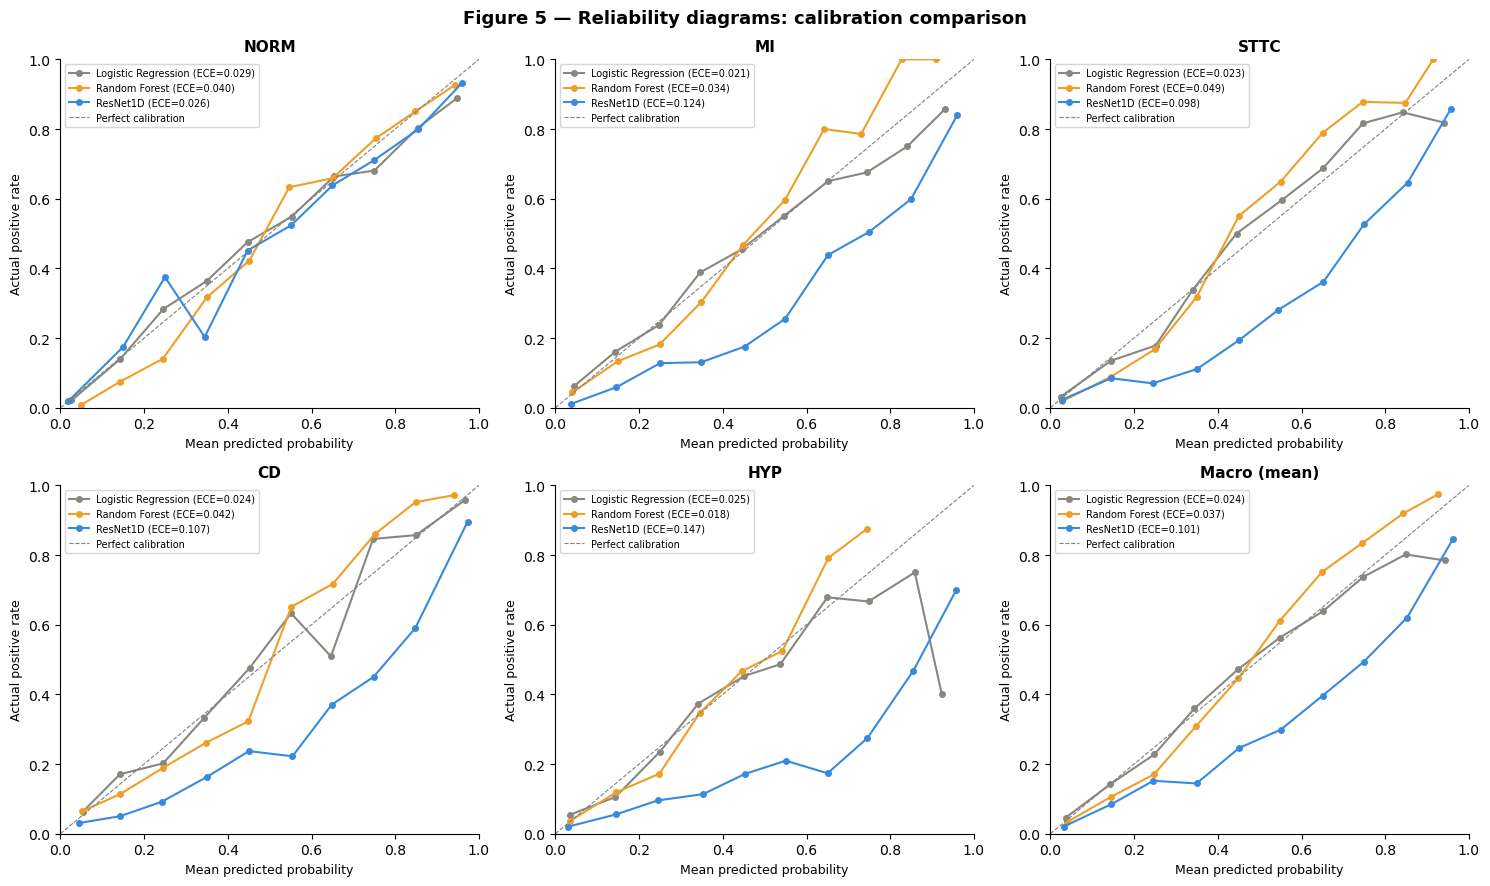

Figure 5 saved


In [11]:
def figure5_calibration() -> plt.Figure:
    """
    Reliability diagrams for all three models.
    """
    model_probs = {
        'Logistic Regression': lr_test_probs,
        'Random Forest':       rf_test_probs,
        'ResNet1D':            resnet_test_probs,
    }

    n_bins    = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes      = axes.flatten()

    for i, cls in enumerate(CLASS_ORDER):
        ax = axes[i]
        for model_name, probs in model_probs.items():
            bin_confs = []
            bin_accs  = []
            for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
                mask = (probs[:, i] >= lo) & (probs[:, i] < hi)
                if mask.sum() == 0:
                    continue
                bin_confs.append(probs[:, i][mask].mean())
                bin_accs.append(test_labels[:, i][mask].mean())
            ece = compute_ece(test_labels[:, i], probs[:, i])
            ax.plot(bin_confs, bin_accs,
                    color=MODEL_COLORS[model_name],
                    linewidth=1.5, marker='o', markersize=4,
                    label=f"{model_name} (ECE={ece:.3f})")

        ax.plot([0, 1], [0, 1], color='gray',
                linewidth=0.8, linestyle='--',
                label='Perfect calibration')
        ax.set_title(cls, fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean predicted probability', fontsize=9)
        ax.set_ylabel('Actual positive rate', fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.legend(fontsize=7, loc='upper left')
        sns.despine(ax=ax)

    # Macro subplot
    ax = axes[5]
    for model_name, probs in model_probs.items():
        all_confs = []
        all_accs  = []
        for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
            confs = []; accs = []
            for i in range(len(CLASS_ORDER)):
                mask = (probs[:, i] >= lo) & (probs[:, i] < hi)
                if mask.sum() == 0:
                    continue
                confs.append(probs[:, i][mask].mean())
                accs.append(test_labels[:, i][mask].mean())
            if confs:
                all_confs.append(np.mean(confs))
                all_accs.append(np.mean(accs))
        macro_ece = np.mean([compute_ece(test_labels[:, i],
                             probs[:, i]) for i in range(5)])
        ax.plot(all_confs, all_accs,
                color=MODEL_COLORS[model_name],
                linewidth=1.5, marker='o', markersize=4,
                label=f"{model_name} (ECE={macro_ece:.3f})")

    ax.plot([0, 1], [0, 1], color='gray',
            linewidth=0.8, linestyle='--',
            label='Perfect calibration')
    ax.set_title('Macro (mean)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean predicted probability', fontsize=9)
    ax.set_ylabel('Actual positive rate', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='upper left')
    sns.despine(ax=ax)

    fig.suptitle('Figure 5 — Reliability diagrams: calibration comparison',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

fig5 = figure5_calibration()
plt.show()
fig5.savefig(FIGURES / 'figure5_calibration.png',
             dpi=150, bbox_inches='tight')
print("Figure 5 saved")

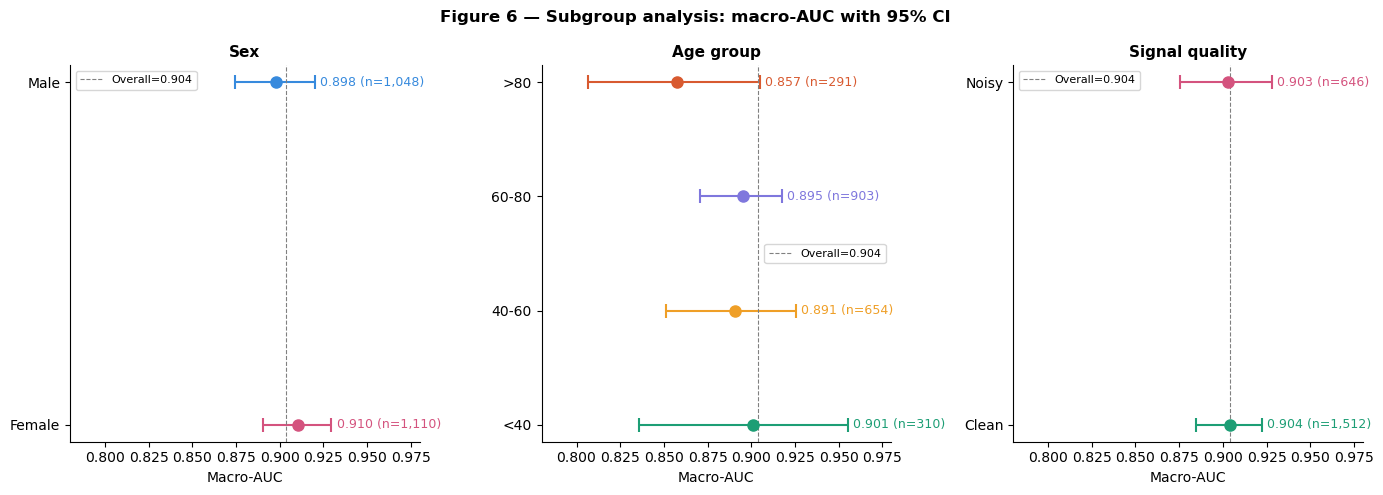

Figure 6 saved


In [12]:
def figure6_subgroup() -> plt.Figure:
    """
    Three-panel forest plot showing subgroup macro-AUC.
    """
    import openpyxl

    groups = {
        'Sex':            ['Female', 'Male'],
        'Age group':      ['<40', '40-60', '60-80', '>80'],
        'Signal quality': ['Clean', 'Noisy'],
    }

    SUBGROUP_COLORS = {
        'Female': '#D4537E', 'Male':   '#378ADD',
        '<40':    '#1D9E75', '40-60':  '#EF9F27',
        '60-80':  '#7F77DD', '>80':    '#D85A30',
        'Clean':  '#1D9E75', 'Noisy':  '#D4537E',
    }

    # Load all subgroup sheets
    subgroup_data = {}
    for name in ['Female', 'Male', 'lt40', '40_60',
                 '60_80', 'gt80', 'Clean', 'Noisy']:
        df_s = pd.read_excel(
            ARTIFACTS / 'subgroup_analysis.xlsx',
            sheet_name=name, index_col=0
        )
        # Map safe names back to display names
        display = (name.replace('lt', '<').replace('gt', '>')
                       .replace('_', '-'))
        subgroup_data[display] = df_s

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    for ax, (group_name, subgroup_names) in zip(axes, groups.items()):
        y_pos = np.arange(len(subgroup_names))

        for i, name in enumerate(subgroup_names):
            df_s  = subgroup_data[name]
            macro = df_s.loc['Macro (mean)']
            est   = macro['AUC']
            lo    = macro['CI Lower']
            hi    = macro['CI Upper']
            n     = int(macro['N'])
            color = SUBGROUP_COLORS.get(name, '#888780')

            ax.errorbar(
                x=est, y=i,
                xerr=[[est - lo], [hi - est]],
                fmt='o', color=color, ecolor=color,
                elinewidth=1.5, capsize=5,
                capthick=1.5, markersize=8
            )
            ax.text(hi + 0.003, i,
                    f"{est:.3f} (n={n:,})",
                    va='center', fontsize=9, color=color)

        ax.axvline(0.9038, color='gray', linewidth=0.8,
                   linestyle='--', label='Overall=0.904')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(subgroup_names, fontsize=10)
        ax.set_xlabel('Macro-AUC', fontsize=10)
        ax.set_title(group_name, fontsize=11, fontweight='bold')
        ax.set_xlim(0.78, 0.98)
        ax.legend(fontsize=8)
        sns.despine(ax=ax)

    fig.suptitle('Figure 6 — Subgroup analysis: macro-AUC with 95% CI',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    return fig

fig6 = figure6_subgroup()
plt.show()
fig6.savefig(FIGURES / 'figure6_subgroup.png',
             dpi=150, bbox_inches='tight')
print("Figure 6 saved")

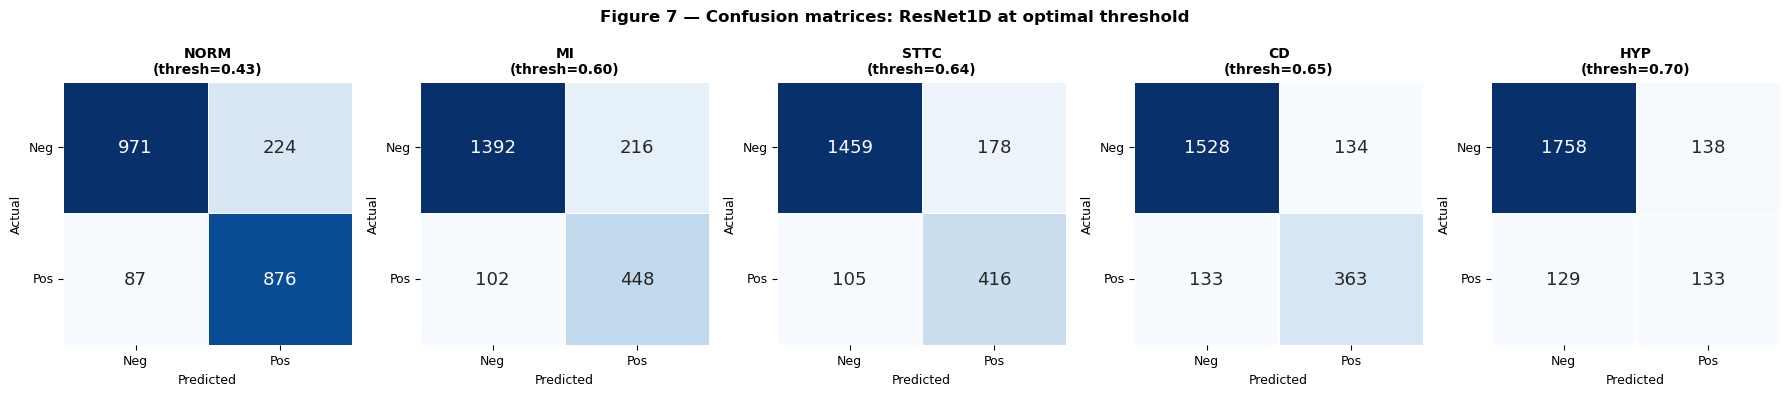

Figure 7 saved


In [13]:
import modeling

def figure7_confusion_matrices() -> plt.Figure:
    """
    Confusion matrices for ResNet1D at optimal threshold,
    one per diagnostic superclass.
    """
    # Load optimal thresholds
    resnet_thresholds = np.array([
        modeling.find_optimal_threshold(
            test_labels[:, i], resnet_test_probs[:, i]
        )
        for i in range(len(CLASS_ORDER))
    ])

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    for i, (cls, ax) in enumerate(zip(CLASS_ORDER, axes)):
        thresh = resnet_thresholds[i]
        preds  = (resnet_test_probs[:, i] >= thresh).astype(int)
        cm     = confusion_matrix(test_labels[:, i], preds)

        sns.heatmap(
            cm,
            annot      = True,
            fmt        = 'd',
            cmap       = 'Blues',
            ax         = ax,
            cbar       = False,
            linewidths = 0.5,
            linecolor  = 'white',
            annot_kws  = {'size': 13, 'weight': '500'}
        )
        ax.set_title(f"{cls}\n(thresh={thresh:.2f})",
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual',    fontsize=9)
        ax.set_xticklabels(['Neg', 'Pos'], fontsize=9)
        ax.set_yticklabels(['Neg', 'Pos'], fontsize=9, rotation=0)

    fig.suptitle('Figure 7 — Confusion matrices: ResNet1D at optimal threshold',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    return fig

fig7 = figure7_confusion_matrices()
plt.show()
fig7.savefig(FIGURES / 'figure7_confusion_matrices.png',
             dpi=150, bbox_inches='tight')
print("Figure 7 saved")

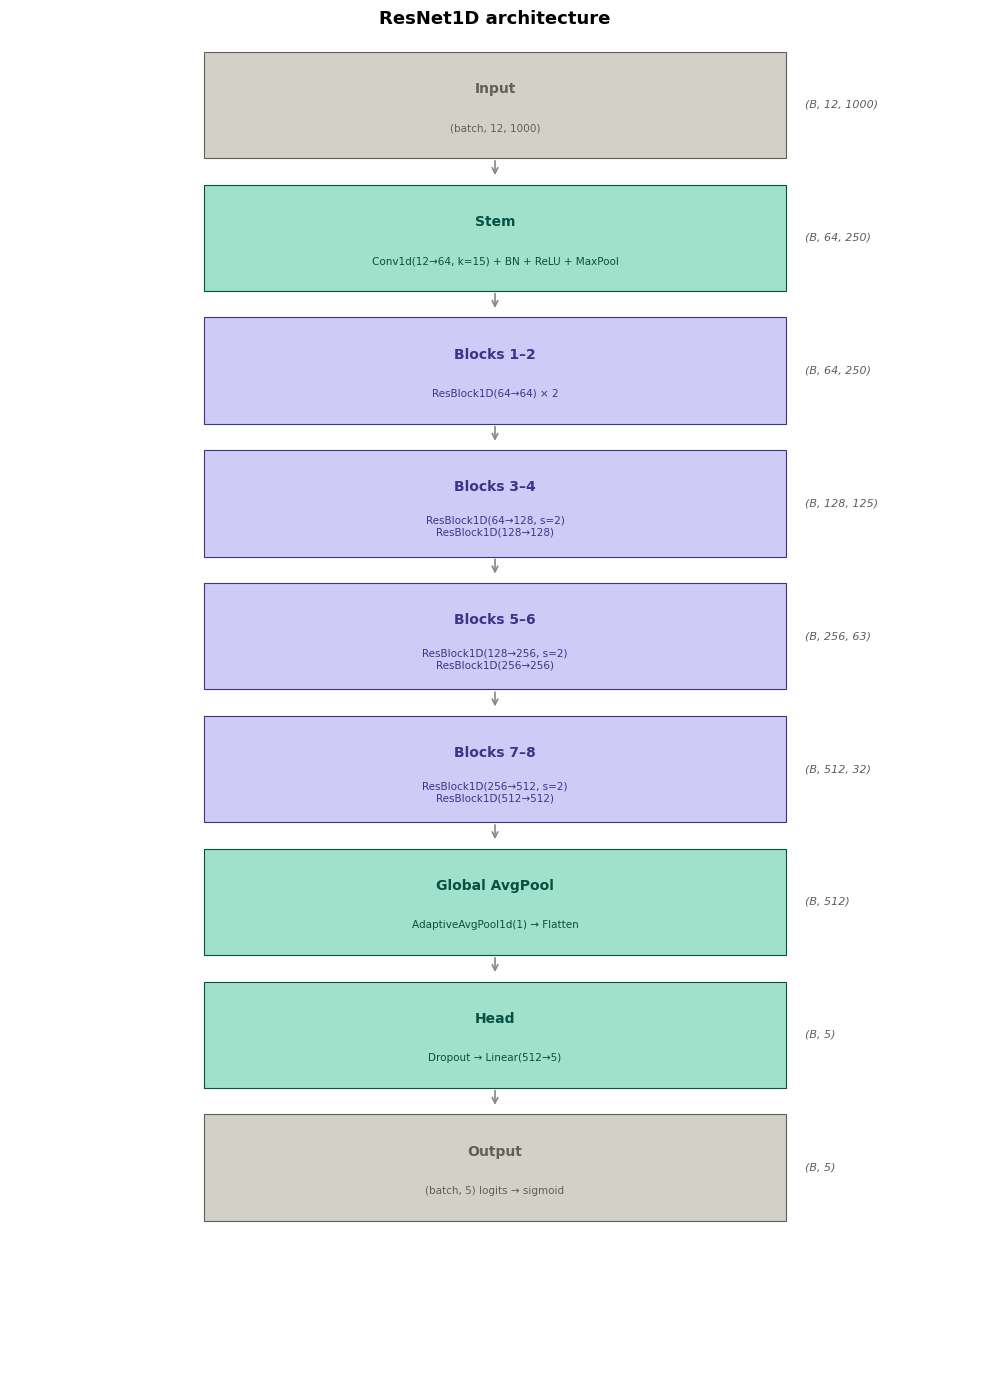

Architecture figure saved


In [14]:
def plot_resnet1d_architecture() -> plt.Figure:
    """
    Plot ResNet1D architecture as a static diagram.

    Returns:
        plt.Figure
    """
    fig, ax = plt.subplots(figsize=(10, 14))
    ax.axis('off')

    # Define blocks
    blocks = [
        ('Input',         '(batch, 12, 1000)',          '#D3D1C7', '#5F5E5A'),
        ('Stem',          'Conv1d(12→64, k=15) + BN + ReLU + MaxPool', '#9FE1CB', '#085041'),
        ('Blocks 1–2',    'ResBlock1D(64→64) × 2',      '#CECBF6', '#3C3489'),
        ('Blocks 3–4',    'ResBlock1D(64→128, s=2)\nResBlock1D(128→128)', '#CECBF6', '#3C3489'),
        ('Blocks 5–6',    'ResBlock1D(128→256, s=2)\nResBlock1D(256→256)', '#CECBF6', '#3C3489'),
        ('Blocks 7–8',    'ResBlock1D(256→512, s=2)\nResBlock1D(512→512)', '#CECBF6', '#3C3489'),
        ('Global AvgPool','AdaptiveAvgPool1d(1) → Flatten', '#9FE1CB', '#085041'),
        ('Head',          'Dropout → Linear(512→5)',    '#9FE1CB', '#085041'),
        ('Output',        '(batch, 5) logits → sigmoid','#D3D1C7', '#5F5E5A'),
    ]

    # Shape annotations on the right
    shapes = [
        '(B, 12, 1000)',
        '(B, 64, 250)',
        '(B, 64, 250)',
        '(B, 128, 125)',
        '(B, 256, 63)',
        '(B, 512, 32)',
        '(B, 512)',
        '(B, 5)',
        '(B, 5)',
    ]

    box_width  = 0.6
    box_height = 0.08
    x_center   = 0.5
    gap        = 0.02
    total      = len(blocks)

    for i, ((title, subtitle, fill, text_color), shape) in enumerate(
            zip(blocks, shapes)):

        # Y position from top
        y = 1.0 - (i * (box_height + gap)) - box_height

        # Draw box
        rect = plt.Rectangle(
            (x_center - box_width / 2, y),
            box_width, box_height,
            facecolor=fill, edgecolor=text_color,
            linewidth=0.8, transform=ax.transAxes,
            clip_on=False
        )
        ax.add_patch(rect)

        # Title text
        ax.text(x_center, y + box_height * 0.65, title,
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color=text_color,
                transform=ax.transAxes)

        # Subtitle text
        ax.text(x_center, y + box_height * 0.28, subtitle,
                ha='center', va='center',
                fontsize=7.5, color=text_color,
                transform=ax.transAxes)

        # Shape annotation on right
        ax.text(x_center + box_width / 2 + 0.02,
                y + box_height / 2,
                shape,
                ha='left', va='center',
                fontsize=8, color='#5F5E5A',
                transform=ax.transAxes,
                style='italic')

        # Arrow between boxes
        if i < total - 1:
            arrow_y = y
            ax.annotate('',
                xy=(x_center, arrow_y - gap + 0.005),
                xytext=(x_center, arrow_y),
                xycoords='axes fraction',
                textcoords='axes fraction',
                arrowprops=dict(
                    arrowstyle='->', color='#888780',
                    lw=1.2
                ))

    ax.set_title('ResNet1D architecture',
                 fontsize=13, fontweight='bold', pad=20)

    fig.tight_layout()
    return fig


fig_arch = plot_resnet1d_architecture()
plt.show()
fig_arch.savefig(FIGURES / 'architecture.png', dpi=150, bbox_inches='tight')
print("Architecture figure saved")

In [15]:
# ── Summary print ─────────────────────────────────────────────────────────────
figures = {
    'Figure 1 — Model comparison':        fig1,
    'Figure 2 — Per-class AUC':           fig2,
    'Figure 3 — ROC curves':              fig3,
    'Figure 4 — Sensitivity/Specificity': fig4,
    'Figure 5 — Calibration':             fig5,
    'Figure 6 — Subgroup analysis':       fig6,
    'Figure 7 — Confusion matrices':      fig7,
}

print(f"\nAll figures saved to: {FIGURES}")
for name in figures:
    print(f"  ✓ {name}")


All figures saved to: c:\Users\delga\OneDrive\Documents\personal_projects\DeepAF Automated Atrial Fibrillation Detection\ecg-ai-statistical-evaluation\figures
  ✓ Figure 1 — Model comparison
  ✓ Figure 2 — Per-class AUC
  ✓ Figure 3 — ROC curves
  ✓ Figure 4 — Sensitivity/Specificity
  ✓ Figure 5 — Calibration
  ✓ Figure 6 — Subgroup analysis
  ✓ Figure 7 — Confusion matrices
